# <center>Weekly Engineering Assignment 6 - Group 3 - S23</center><br><center>Population Dynamics</center>
<span hidden>ENGR010SP23EN06GR03</span>

My boss wants me to solve a simple cell culture population dynamics problem using the Scipy library in Python.<br>
Firstly, organize some constants and define the equation.<br>
Then follow the instructions and derive the desired value.

## Section 1: Population Change Projection

<b>Step 1: Import code modules</b>

Follow the steps, as instructed kindly.<br>
Import modules - Define function - Find the solution - Plot and compare results.<br>
In this step, I need to import the modules follow as; 1.numpy, 2. matplotlib.pyplot 3. fsolve


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

<b>Step 2: Define the function</b>

'dP/dt = equation' should be defined in this step. Also, define the constants too

In [4]:
r = 0.00231
T = 1000
K = 1000000

def equation(P):
    return -r * P[0] * (1 - P/K) * (1 - P/T)


<b>Step 3: Find the solutions near $P=0$, $P=T$, and $P=K$</b>

Find the 3 answers(three P values). At this time, use fsolve to find the solution.<br>
And I can prove it by checking if the same value comes out using a other initial guess value(100, 1.1T, 1.1K).

In [5]:
# P = 0 and P = 100
print(fsolve(equation, 0))
print(fsolve(equation, 100))

[0.]
[0.]


In [6]:
# P = T and P = 1.1T (T = 1000)
print(fsolve(equation, T))
print(fsolve(equation, 1.1*T))

[1000.]
[1000.]


In [7]:
# P = K and P = 1.1K (P = 1000000)
print(fsolve(equation, K))
print(fsolve(equation, 1.1*K))

[1000000.]
[1000000.]


<b>Step 4: Plot function vs. population values</b>

Declare the given scope first.<br>
The result value corresponding to the given range is calculated by substituting the function.<br>
I can draw a picture with those values.

In [8]:
range_1 = np.linspace(0, 1000, 100)
range_2 = np.linspace(1000, 1000000, 100) 
range_3 = np.linspace(1000000, 10000000, 100)

output_1 = equation(range_1)
output_2 = equation(range_2)
output_3 = equation(range_3)


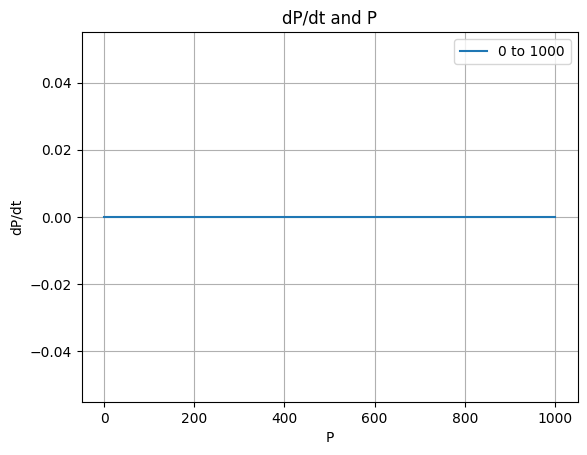

In [9]:
# first graph (range_1 and output_1)
plt.plot(range_1, output_1, label='0 to 1000')
plt.xlabel('P')
plt.ylabel('dP/dt')
plt.title('dP/dt and P')
plt.legend()
plt.grid(True)
plt.show()

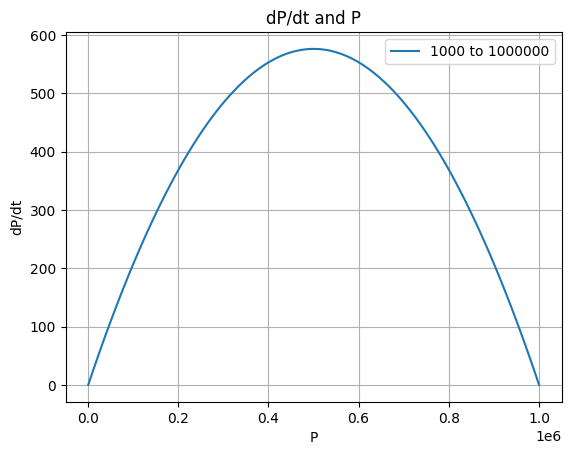

In [10]:
# second graph (range_2 and output_2)
plt.plot(range_2, output_2, label='1000 to 1000000')
plt.xlabel('P')
plt.ylabel('dP/dt')
plt.title('dP/dt and P')
plt.legend()
plt.grid(True)
plt.show()

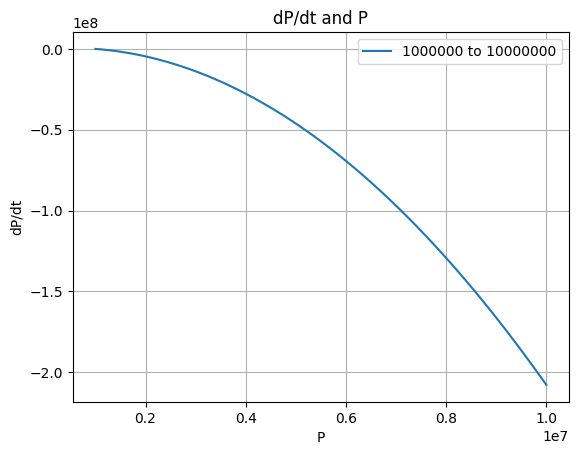

In [11]:
# third graph (range_3 and output_3)
plt.plot(range_3, output_3, label='1000000 to 10000000')
plt.xlabel('P')
plt.ylabel('dP/dt')
plt.title('dP/dt and P')
plt.legend()
plt.grid(True)
plt.show()

<b>Step 5: Summary</b>

P=0: Understanding indicates that there are no cells in the cell culture. This means that the cell is completely gone or the initial state in which the cell does not exist yet.<br>
P=T: The understanding indicates that the number of cells is equal to the threshold value of T. In other words, it means that the number of cells exceeds a certain level and growth begins to occur.<br>
P=K: The understanding indicates that the number of cells is equal to K, which is the carrying capacity. This means that the number of cells reaches the maximum allowable amount of K of the culture medium, and the growth stops.(Then, its population shrinks)<br>

The population change of the cell can be examined according to the movement of the above graph.<br>
There are Three sections<br>
1. 0 < P < T : There has been no increase or decrease in population so far
2. T < P < K : The population grows rapidly and eventually stagnates as the rate of increase slowly decreases.
3. K < P : The population decreases


## Section 2: Population Projection

Here too, I can follow the instructions below.
1. Import new modules
2. Solve the 4 cases
3. Declare the right number for each case and use a common equation, solve_ivp function.

<b>Step 1: Import code modules</b>

I already import the other module(numpy, matplotlib ...), So, in this step, I need to import the solve_ivp

In [12]:
from scipy.integrate import solve_ivp

<b>Step 2: Case 1 - Starts $P=0.50K$ and threshold at $P_{targ}=0.99K$</b>

Anyway, I'm going to try a number of different cases. So I'm going to solve this by declaring one function.

In [13]:
t_span = (0, 100000) # It is an arbitrary time range. If it's not enough, increase it and decrease it if it's too big.
K = 1000000  # constant
T = 1000 # constant
r = 0.00231 # constant

# The function to slove each case and declare the constants to use in duplicate cases.
def basic_equation(t,p):
    return -r * p * (1-p/K)*(1-p/T)



def get(initial, target, t_span):
    result = solve_ivp(basic_equation, t_span, [initial])
    result_n = np.round_(result.t,6)
    result_y = np.round_(result.y,6)
    idx = 0
    if target <= initial: #If the initial population is less than 1000, the population decreases, so control parameters are set accordingly
        sw = 1
    else:
        sw = 2

    if sw == 2:
        for i in range(len(result.t)):
            if result_y[0][i] >= target and sw == 2: #Save the point of arrival.
                idx = i # Save the value
                sw = 0
    else:
        for i in range(len(result.t)):
            if result_y[0][i] <= target and sw == 1: #Save the point of arrival.
                idx = i # Save the value
                sw = 0

    plt.figure()
    plt.plot(result_n, result_y[0], label='Population')
    plt.axhline(y=target, color='r', linestyle='--', label='Target Population')
    plt.xlabel('Time')
    plt.ylabel('Population')
    plt.title('Population Growth Over Time')
    plt.legend()
    plt.grid(True)
    plt.show()

    return result_n[idx] #Through this value, the t_span value can be arbitrarily adjusted. (The time value after the target is reached makes the graph more difficult to see.)

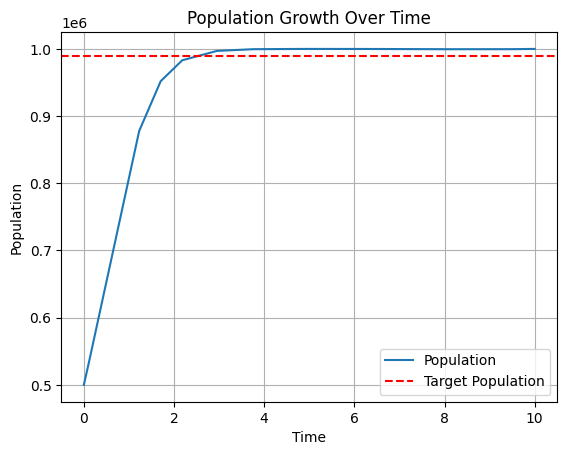

2.954023

In [14]:
# first case
t_span = (0, 10)
P0 = 0.50 * K  # initial
Ptarg = 0.99 * K  # target

get(P0, Ptarg, t_span)

<b>Step 3: Case 2 - Starts $P=T+1$ and threshold at $P_{targ}=0.99K$</b>

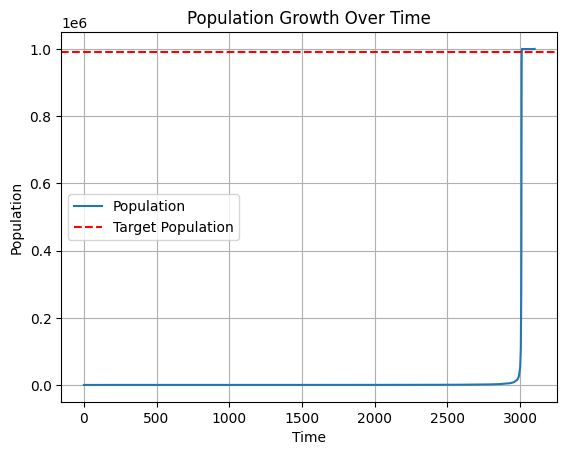

3011.243308

In [15]:
t_span = (0,3100)
P1 = T + 1  # initial
Ptarg = 0.99 * K  # target

get(P1, Ptarg, t_span) #It doesn't seem to change until about 2,500 on the graph, but it increases little by little and then increases rapidly when it reaches a certain value

<b>Step 4: Case 3 - Starts $P=T-1$ and threshold at $P_{targ}=1$</b>

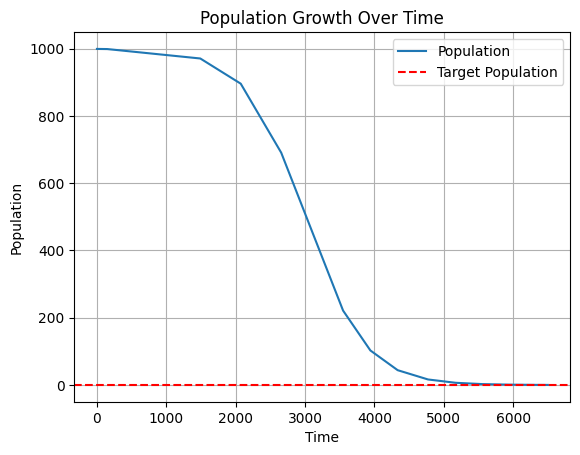

6322.734969


In [16]:
P2 = T - 1  # initial
Ptarg = 1  # target
t_span = (0, 6500)
print(get(P2, Ptarg, t_span))

<b>Step 5: Case 4 - Starts $P=1.5K$ and threshold at $P_{targ}=1.01K$</b>

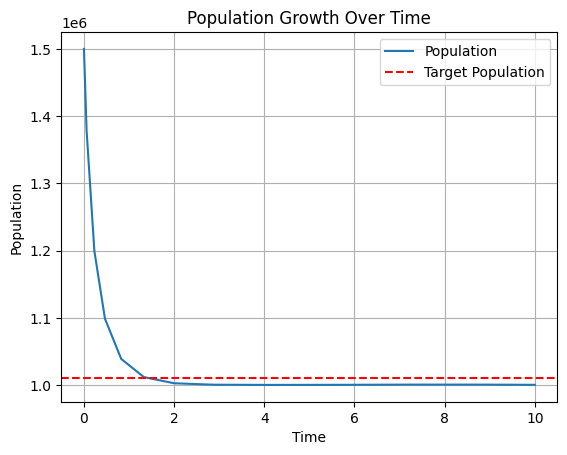

2.00105


In [17]:
P3 = 1.5*K  # initial
Ptarg = 1.01*K  # target
t_span = (0,10)

print(get(P3, Ptarg, t_span))

## Section 3: Automating Optimization

In Section 2, in order to obtain the arbitrary time width more freely, the idx value was obtained, returned, and then the value was derived first, and the solution to that part is presented here. <br>
I saved the time to reach the target value at the same time as forming the data value of the graph in Section 2, and in this section, the time to reach the target value is first calculated, and then the arbitrary time width is selected based on the value.

In [18]:
K = 1000000  # constant
T = 1000 # constant
r = 0.00231 # constant

def basic_equation(t,p):
    return -r * p * (1-p/K)*(1-p/T)

# Function that returns the time it takes to reach the target
def get_time(initial, target, t_span): # this function is equal to fsolve or root_scalar
    result = solve_ivp(basic_equation, t_span, [initial])
    result_n = np.round_(result.t,6)
    result_y = np.round_(result.y,6)
    
    if target <= initial: #If the initial population is less than 1000, the population decreases, so control parameters are set accordingly
        sw = 1
    else:
        sw = 2

    if sw == 2:
        for i in range(len(result.t)):
            if result_y[0][i] >= target and sw == 2: #Save the point of arrival. - This if statement is equalt to 'P(targ) - P(t) = 0'
                return result_n[i] 
    else:
        for i in range(len(result.t)):
            if result_y[0][i] <= target and sw == 1: #Save the point of arrival. - This if statement is equalt to 'P(targ) - P(t) = 0'
                sw = 0
                return result_n[i] 




case 1 t: 2.954023
case 2 t: 3011.61746
case 3 t: 6322.734969
case 4 t: 2.00105
-------------------------------
CASE 1, initial value is: 500000, target value is : 990000


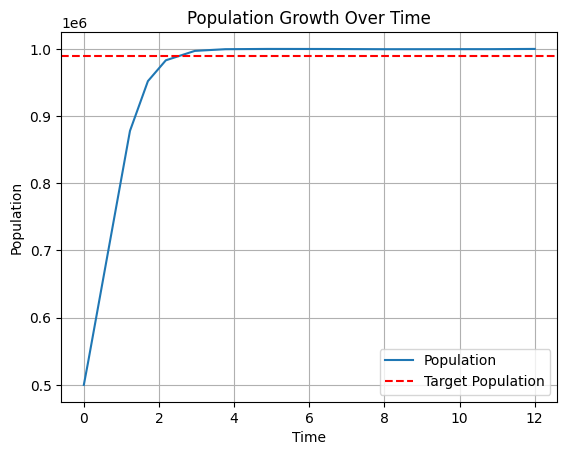

CASE 2, initial value is: 1001, target value is : 990000


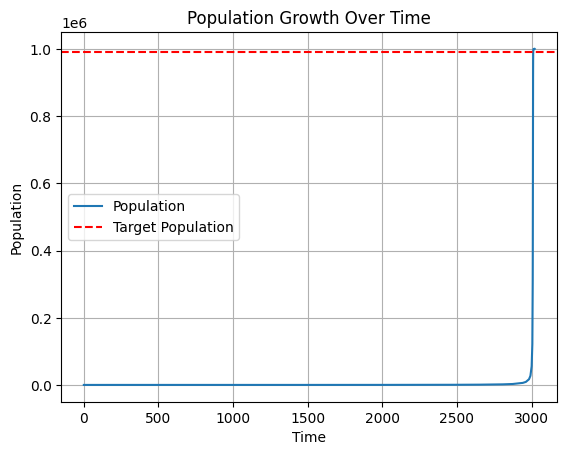

CASE 3, initial value is: 999, target value is : 1


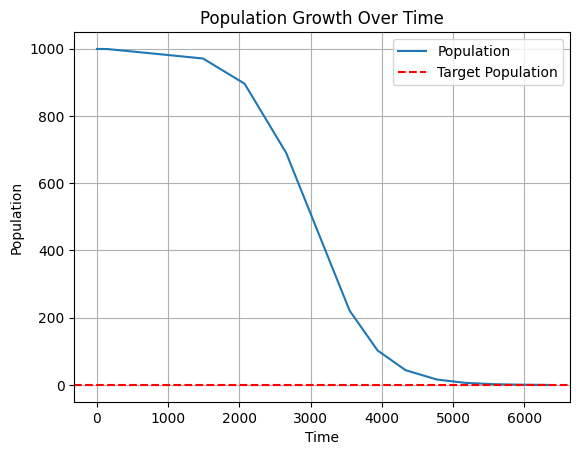

CASE 4, initial value is: 1500000, target value is : 1010000


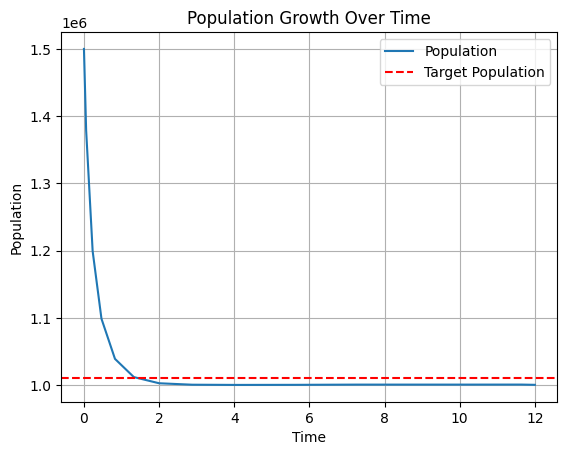

In [38]:
# Test
initial_populations = [0.5*K, T+1, T-1, 1.5*K]
target_populations = [0.99*K, 0.99*K, 1, 1.01*K]
time = []
t_span = (0, 10000)

for i in range(len(initial_populations)):
    print("case %d t:" %(i+1), end = " ")
    time.append(get_time(initial_populations[i], target_populations[i], t_span))
    print(time[i])
idx = 0
print("-------------------------------")
for t in time:
    t = int(t)
    t_span = (0, t+10)
    print("CASE %d, initial value is: %d, target value is : %d" %(idx+1, initial_populations[idx], target_populations[idx]))
    get(initial_populations[idx], target_populations[idx], t_span)
    idx += 1

This engineering task required considerable thought. This equation of population change is that the number of people below 1000 approaches zero at the start, and when it is above 1000, the number of people increases to 10,000,000. In addition, when the initial population is more than 1,000,000, the population converges to 1,000,000. I made this as a function and painted four cases that takes place to suit each case. As a result, it is possible to draw the graph with desired start value and the target value. But there was one problem here: different time zones. Cases 1 and 4 have a t value of less than 3, while numbers 2 and 3 have a value of more than 3000. If the width of the t-value is always fixed and set to a large width to represent all values, the appearance of the graph becomes inefficient. To prevent it, the value of t taken to reach it was first obtained and then a graph was drawn based on it in section 3. I was told to use fsolve or root_scaler, but in case 2, I already got the time value using scipy's solve_ivp, so I applied it right away. As a result, I was able to draw graphs faster and more efficiently.

<span hidden>ENGR010SP23EN06GR03230326</span>